In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.decomposition import PCA
# Note absence of StandardScaler import from sklearn.preprocessing, since all units in pps

Define Font Family for Charts

In [2]:
plt.rcParams['font.family'] = 'Calibri'

Specify Pandas Observation Formatting

In [3]:
pd.options.display.float_format = '{:.4f}'.format

Import Yield Data from BoC

In [4]:
raw_yield_data = pd.read_csv(r"/Users/jdawg/Downloads/bond_yields_all.csv", skiprows=27)
# Note that we skipped 27 rows on csv import given BoC data begins on line 28

# For other users, put the filepath to the downloaded CSV (from the BoC) above

Define Columns to Keep (2s, 3s, 5s, 7s, 10s, and Longs Benchmark Yields) and Rename Columns

In [5]:
columns_to_keep = ["BD.CDN.2YR.DQ.YLD",
                       "BD.CDN.3YR.DQ.YLD",
                       "BD.CDN.5YR.DQ.YLD",
                       "BD.CDN.7YR.DQ.YLD",
                       "BD.CDN.10YR.DQ.YLD",
                       "BD.CDN.LONG.DQ.YLD"]

column_rename_mapping = {}
for column in columns_to_keep:
    new_column_name = column.split(".")[2]
    column_rename_mapping[column] = new_column_name

yield_data = raw_yield_data[["date"]+columns_to_keep].rename(columns=column_rename_mapping)

Change Data Type of Date Column to Date (from String) and Reassign Index

In [6]:
yield_data["date"] = pd.to_datetime(yield_data["date"])
yield_data = yield_data.set_index("date")

Normalize Levels to DoD Changes (Given as %, Since Raw Data as %) and Drop NA

In [7]:
columns = yield_data.columns
yield_data[columns] = yield_data[columns].diff()
yield_data = yield_data.dropna()

In [8]:
yield_data

,2YR,3YR,5YR,7YR,10YR,LONG
date,,,,,,
2001-01-03,0.0000,0.0300,0.0900,0.1000,0.1500,0.1100
2001-01-04,-0.1200,-0.1000,-0.0800,-0.0700,-0.0400,-0.0100
2001-01-05,-0.1100,-0.1100,-0.1000,-0.1000,-0.0700,-0.0100
2001-01-08,0.0100,0.0200,0.0200,0.0200,0.0300,0.0500
2001-01-09,0.0600,0.0500,0.0500,0.0400,0.0200,-0.0100
...,...,...,...,...,...,...
2026-03-19,0.0900,0.0800,0.0400,0.0000,-0.0100,-0.0400
2026-03-20,0.2300,0.2200,0.1500,0.1500,0.1200,0.1000
2026-03-23,-0.1200,-0.1100,-0.0600,-0.0500,-0.0300,-0.0300


Double-Check We Didn't Get Rid of Too Many Observations By Dropping NA

In [9]:
row_diff = raw_yield_data.shape[0] - yield_data.shape[0]
print("Removed",row_diff,"observations.")

Removed 3 observations.


Initialize PCA and Specify 3 Components

In [10]:
pca = PCA(n_components=3)

Generate Dataframes Corresponding to Factor Returns, Loadings, and Explained Variance

In [11]:
factor_returns = pd.DataFrame(
    pca.fit_transform(yield_data),
    index=yield_data.index,
    columns=["PC1", "PC2", "PC3"]
)
factor_returns

,PC1,PC2,PC3
date,,,
2001-01-03,0.1942,0.1226,-0.0190
2001-01-04,-0.1756,0.0783,0.0012
2001-01-05,-0.2103,0.0610,0.0273
2001-01-08,0.0590,0.0287,0.0199
2001-01-09,0.0910,-0.0471,-0.0172
...,...,...,...
2026-03-19,0.0716,-0.1122,0.0032
2026-03-20,0.3993,-0.0972,0.0477
2026-03-23,-0.1641,0.0783,-0.0324


In [12]:
loadings = pd.DataFrame(
    pca.components_,
    index=["PC1", "PC2", "PC3"],
    columns=yield_data.columns
)
loadings

,2YR,3YR,5YR,7YR,10YR,LONG
PC1,0.4023,0.4168,0.4480,0.4407,0.4148,0.3122
PC2,-0.5401,-0.4496,-0.0225,0.1708,0.3896,0.5698
PC3,0.3633,0.1897,-0.4842,-0.3995,-0.0892,0.6557


In [13]:
variance_explained = pd.DataFrame(
    pca.explained_variance_ratio_,
    index = ["PC1", "PC2", "PC3"],
    columns = ["Variance Explained"]
)
variance_explained

,Variance Explained
PC1,0.8900
PC2,0.0762
PC3,0.0129


Generate Cumulative Return Series

In [14]:
cumulative_returns = factor_returns.cumsum()
cumulative_returns

,PC1,PC2,PC3
date,,,
2001-01-03,0.1942,0.1226,-0.0190
2001-01-04,0.0187,0.2009,-0.0178
2001-01-05,-0.1917,0.2620,0.0094
2001-01-08,-0.1327,0.2907,0.0294
2001-01-09,-0.0417,0.2436,0.0122
...,...,...,...
2026-03-19,-0.1056,0.0194,-0.0114
2026-03-20,0.2937,-0.0778,0.0363
2026-03-23,0.1296,0.0005,0.0039


Plot Cumulative Returns Series

<Axes: title={'center': 'Cumulative Factor Returns'}, xlabel='date'>

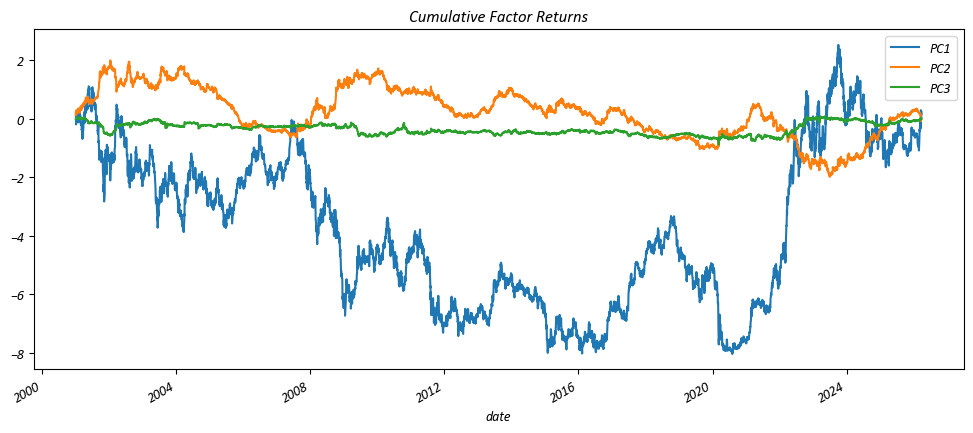

In [15]:
cumulative_returns.plot(figsize=(12, 5), title="Cumulative Factor Returns")

Plot PCA Factor Loadings

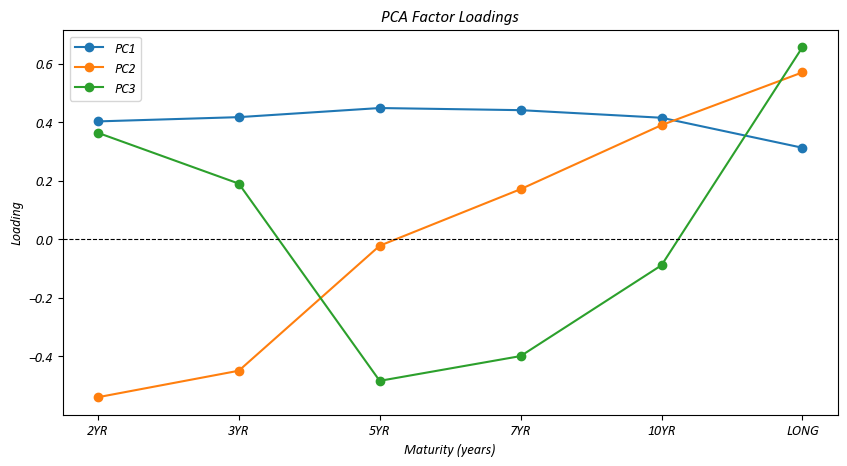

In [16]:
loadings.T.plot(figsize=(10, 5), marker="o", title="PCA Factor Loadings") #T.plot transposes our dataframe so we plot maturities on the x-axis
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Maturity (years)")
plt.ylabel("Loading")
plt.show()

Calculate 125d/250d Rolling Vols

In [17]:
rolling_vol_125 = factor_returns.rolling(125).std().dropna()
rolling_vol_250 = factor_returns.rolling(250).std().dropna()

Plot Rolling Vols

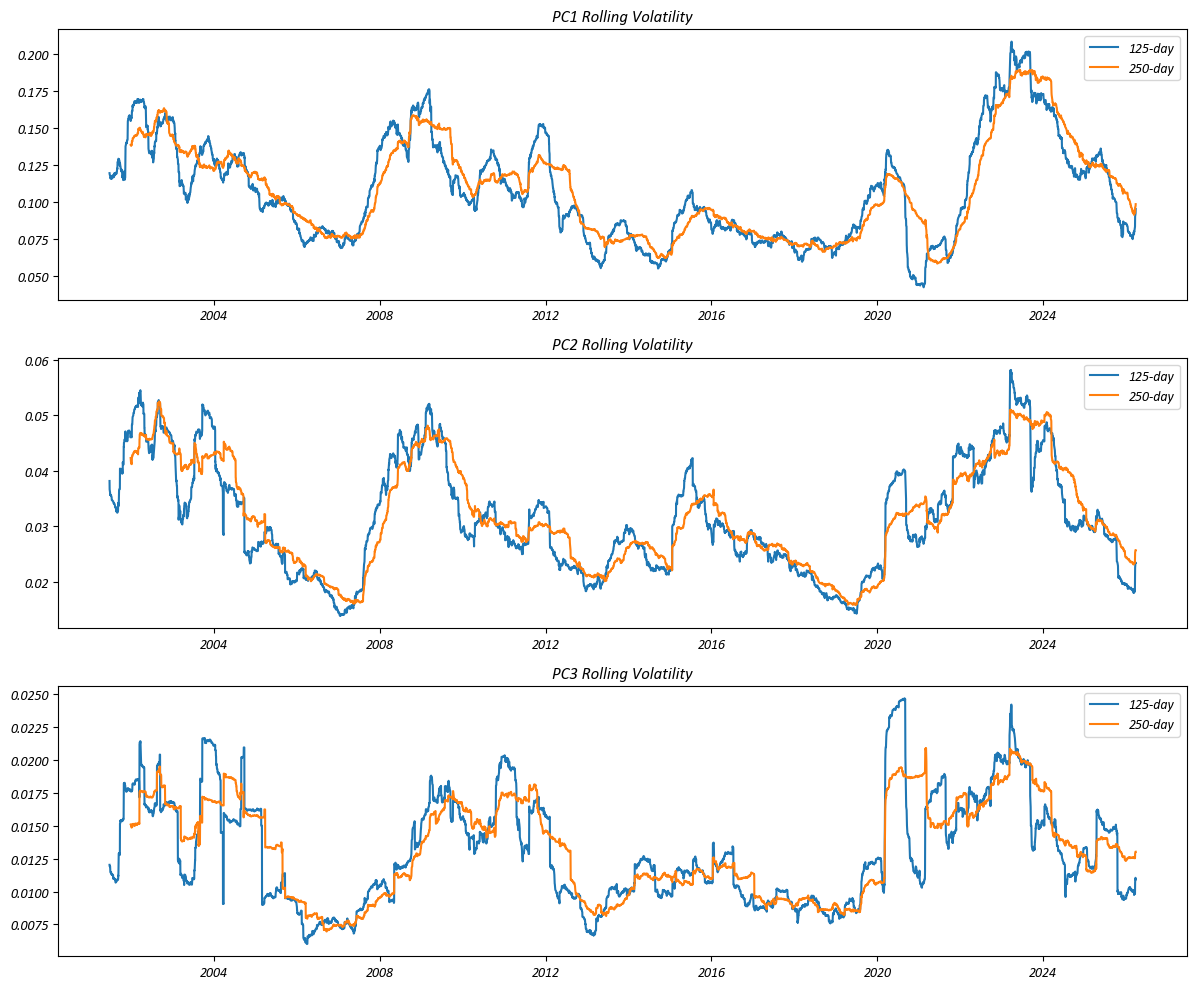

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    axes[i].plot(rolling_vol_125[pc], label="125-day")
    axes[i].plot(rolling_vol_250[pc], label="250-day")
    axes[i].set_title(f"{pc} Rolling Volatility")
    axes[i].legend()

plt.tight_layout()
plt.show()

Define Timeframe Boundaries

In [19]:
timeframe_start = pd.to_datetime("2022-03-01")
timeframe_end = pd.to_datetime("2022-06-30")

Define and Calculate Curve Segments

In [20]:
curve_shapes = raw_yield_data

columns_to_keep = ["BD.CDN.2YR.DQ.YLD",
                       "BD.CDN.3YR.DQ.YLD",
                       "BD.CDN.5YR.DQ.YLD",
                       "BD.CDN.7YR.DQ.YLD",
                       "BD.CDN.10YR.DQ.YLD",
                       "BD.CDN.LONG.DQ.YLD"]

column_rename_mapping = {}
for column in columns_to_keep:
    new_column_name = column.split(".")[2]
    column_rename_mapping[column] = new_column_name

curve_shapes = curve_shapes[["date"]+columns_to_keep].rename(columns=column_rename_mapping)
curve_shapes["date"] = pd.to_datetime(curve_shapes["date"])
curve_shapes = curve_shapes.set_index("date")

In [21]:
spread_2s10s = curve_shapes["10YR"] - curve_shapes["2YR"]
spread_10s30s = curve_shapes["LONG"] - curve_shapes["10YR"]
spread_2s30s = curve_shapes["LONG"] - curve_shapes["2YR"]
spread_2s5s = curve_shapes["5YR"] - curve_shapes["2YR"]
spread_5s10s = curve_shapes["10YR"] - curve_shapes["5YR"]
fly_2s5s10s = (2*curve_shapes["5YR"]) - curve_shapes["2YR"] - curve_shapes["10YR"]
fly_5s7s10s = (2*curve_shapes["7YR"]) - curve_shapes["5YR"] - curve_shapes["10YR"]
fly_2s10s30s = (2*curve_shapes["10YR"]) - curve_shapes["2YR"] - curve_shapes["LONG"]

Concatenate Curve Segments into a Single DataFrame

In [22]:
curve_shapes = pd.concat([fly_2s10s30s, fly_5s7s10s, fly_2s5s10s, spread_5s10s, spread_2s5s, spread_2s30s, spread_10s30s, spread_2s10s], axis = 1, join = "outer")
curve_shapes = curve_shapes.rename(columns={0:"2s10s30s",1:"5s7s10s",2:"2s5s10s",3:"5s10s",4:"2s5s",5:"2s30s",6:"10s30s",7:"2s10s"})

Trim Curves to Our Given Timeframe (March - June 2022)

In [23]:
curve_shapes_timeframe = curve_shapes.loc[timeframe_start:timeframe_end]
curve_shapes_timeframe

,2s10s30s,5s7s10s,2s5s10s,5s10s,2s5s,2s30s,10s30s,2s10s
date,,,,,,,,
2022-03-01,0.1000,-0.1700,-0.0800,0.2300,0.1500,0.6600,0.2800,0.3800
2022-03-02,0.1000,-0.1400,-0.0600,0.2000,0.1400,0.5800,0.2400,0.3400
2022-03-03,0.0600,-0.1500,-0.0800,0.1900,0.1100,0.5400,0.2400,0.3000
2022-03-04,-0.0200,-0.1600,-0.1200,0.2000,0.0800,0.5800,0.3000,0.2800
2022-03-07,0.0100,-0.1500,-0.1100,0.2100,0.1000,0.6100,0.3000,0.3100
...,...,...,...,...,...,...,...,...
2022-06-24,0.2200,-0.0100,-0.0600,0.1300,0.0700,0.1800,-0.0200,0.2000
2022-06-27,0.2400,-0.0200,-0.0700,0.1400,0.0700,0.1800,-0.0300,0.2100
2022-06-28,0.2400,-0.0100,-0.0700,0.1300,0.0600,0.1400,-0.0500,0.1900


Plot Curve Spreads

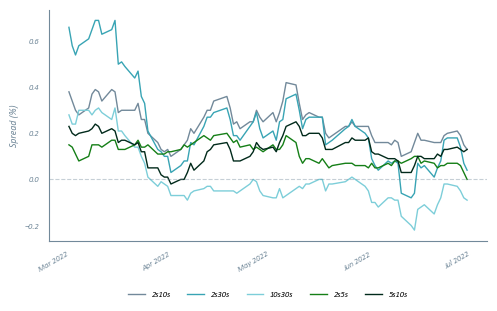

In [24]:
#desired pptx dimensions
fig1, ax1 = plt.subplots(figsize=(5.07, 3.27))

#colour formatting
spread_colours = [c.encode('ascii', 'ignore').decode() for c in ['#72899a', '#38A4B4', '#7DCED9', '#157F17', '#012A1B']]
#curves
spread_cols = ['2s10s', '2s30s', '10s30s', '2s5s', '5s10s']
#map curves to colours and plot
for col, c in zip(spread_cols, spread_colours):
    ax1.plot(curve_shapes_timeframe.index, curve_shapes_timeframe[col],
             color=c, linewidth=1, label=col)

#axis formatting
ax1.axhline(0, color='#72899A', linewidth=0.8, linestyle='--', alpha=0.4)
ax1.set_ylabel('Spread (%)', fontsize=7, color='#72899A')
ax1.set_xlabel('')
ax1.legend(frameon=False, fontsize=6, ncol=5,
           loc='lower center', bbox_to_anchor=(0.5, -0.28))

#remove gridlines and format axis further
ax1.grid(False)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#72899A')
ax1.tick_params(bottom=False, left=False, labelsize=6, colors='#72899A')
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

#further graph formatting
fig1.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('/Users/jdawg/Downloads/curves.png', dpi=300, bbox_inches='tight')
plt.show()

Plot Butterfly Spreads

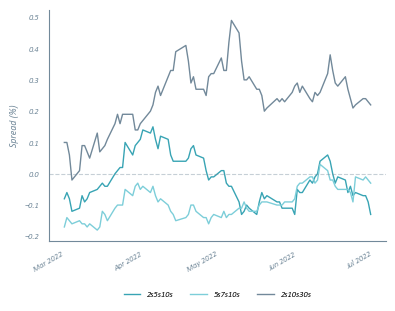

In [25]:
#desired pptx dimensions
fig2, ax2 = plt.subplots(figsize=(4.06, 3.27))

#colour formatting
fly_colors = [c.encode('ascii', 'ignore').decode() for c in ['#38A4B4', '#7DCED9', '#72899A']]
#flies
fly_cols = ['2s5s10s', '5s7s10s', '2s10s30s']
#map flies to colours and plot
for col, c in zip(fly_cols, fly_colors):
    ax2.plot(curve_shapes_timeframe.index, curve_shapes_timeframe[col],
             color=c, linewidth=1, label=col)

#axis formatting
ax2.axhline(0, color='#72899A', linewidth=0.8, linestyle='--', alpha=0.4)
ax2.set_ylabel('Spread (%)', fontsize=7, color='#72899A')
ax2.set_xlabel('')
ax2.legend(frameon=False, fontsize=6, ncol=3,
           loc='lower center', bbox_to_anchor=(0.5, -0.28))

#remove gridlines and format axis further
ax2.grid(False)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#72899A')
ax2.tick_params(bottom=False, left=False, labelsize=6, colors='#72899A')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

#further graph formatting
fig2.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('/Users/jdawg/Downloads/flies.png', dpi=300, bbox_inches='tight')
plt.show()

Summarize Curve and Fly Movements Over Time Period

In [26]:
summary = pd.DataFrame({
    'Start': curve_shapes_timeframe.iloc[0],
    'End':   curve_shapes_timeframe.iloc[-1],
})
summary['Change (bps)'] = (summary['End'] - summary['Start']) * 100
summary

,Start,End,Change (bps)
2s10s30s,0.1000,0.2200,12.0000
5s7s10s,-0.1700,-0.0300,14.0000
2s5s10s,-0.0800,-0.1300,-5.0000
5s10s,0.2300,0.1300,-10.0000
2s5s,0.1500,0.0000,-15.0000
2s30s,0.6600,0.0400,-62.0000
10s30s,0.2800,-0.0900,-37.0000
2s10s,0.3800,0.1300,-25.0000


Examine Factor Returns for Our Timeframe and Generate Summary Stats

In [27]:
factor_returns_timeframe = factor_returns.loc['2022-03-01':'2022-06-30']

period_stats = pd.DataFrame({
    'Mean daily move': factor_returns_timeframe.mean(),
    'Daily vol':       factor_returns_timeframe.std(),
    'Annualised vol':  factor_returns_timeframe.std() * np.sqrt(252),
    'Skewness':        factor_returns_timeframe.skew(),
    'Kurtosis':        factor_returns_timeframe.kurtosis(),
    'Max |move|':      factor_returns_timeframe.abs().max(),
})
period_stats

,Mean daily move,Daily vol,Annualised vol,Skewness,Kurtosis,Max |move|
PC1,0.0420,0.1738,2.7584,-0.1665,-0.3069,0.4501
PC2,-0.0033,0.0419,0.6655,-0.4622,0.3820,0.1342
PC3,0.0018,0.0186,0.2956,-0.6003,1.4135,0.0618


Examine Rolling 125d and 250d Rolling Vols for Our Timeframe

In [28]:
rv_125_timeframe = rolling_vol_125.loc['2022-03-01':'2022-06-30']
rv_250_timeframe = rolling_vol_250.loc['2022-03-01':'2022-06-30']

In [29]:
rv_125_timeframe

,PC1,PC2,PC3
date,,,
2022-03-01,0.1089,0.0424,0.0159
2022-03-02,0.1114,0.0425,0.0159
2022-03-03,0.1114,0.0426,0.0159
2022-03-04,0.1143,0.0423,0.0161
2022-03-07,0.1143,0.0424,0.0161
...,...,...,...
2022-06-24,0.1553,0.0388,0.0169
2022-06-27,0.1555,0.0388,0.0169
2022-06-28,0.1557,0.0389,0.0169


In [30]:
rv_250_timeframe

,PC1,PC2,PC3
date,,,
2022-03-01,0.0907,0.0384,0.0152
2022-03-02,0.0922,0.0383,0.0151
2022-03-03,0.0922,0.0384,0.0150
2022-03-04,0.0937,0.0383,0.0151
2022-03-07,0.0927,0.0383,0.0149
...,...,...,...
2022-06-24,0.1282,0.0410,0.0166
2022-06-27,0.1283,0.0410,0.0166
2022-06-28,0.1283,0.0410,0.0166


Fetch VIX and MOVE Data from Yahoo Finance for Our Timeframe

In [31]:
vix_data = yf.download("^VIX", start="2022-03-01", end="2022-06-30")
move_data = yf.download("^MOVE", start="2022-03-01", end="2022-06-30")

/var/folders/0c/gwf3kkss2ls74cgdgxp9q88r0000gn/T/ipykernel_34822/2395366782.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data = yf.download("^VIX", start="2022-03-01", end="2022-06-30")
[*********************100%***********************]  1 of 1 completed
/var/folders/0c/gwf3kkss2ls74cgdgxp9q88r0000gn/T/ipykernel_34822/2395366782.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  move_data = yf.download("^MOVE", start="2022-03-01", end="2022-06-30")
[*********************100%***********************]  1 of 1 completed


Plot VIX vs. MOVE

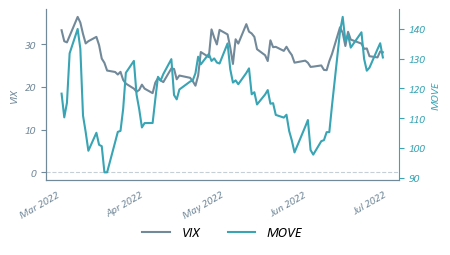

In [32]:
#Set figure size to match pptx
fig, ax = plt.subplots(figsize=(4.56, 2.85))

#Plot VIX closing prices on the left (primary) y-axis
ax.plot(vix_data.index, vix_data[('Close', '^VIX')],
        color='#72899A', linewidth=1.5, label='VIX')

#Add horizontal dashed line at y=0 for visual reference
ax.axhline(0, color='#72899A', linewidth=0.8, linestyle='--', alpha=0.4)

#Label left y-axis and remove x-axis label
ax.set_ylabel('VIX', fontsize=8, color='#72899A', style='italic')
ax.set_xlabel('')

#Remove gridlines
ax.grid(False)

#Format axis spines
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#72899A')

#Remove tick marks, keeping tick labels, and format
ax.tick_params(bottom=False, left=False, labelsize=8, colors='#72899A')

#Show one x-axis label per month
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

#Format x-axis labels as "Mar 2022"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

#Format x-axis labels
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

#Create a secondary (right) y-axis sharing the same x-axis
ax2 = ax.twinx()

#Plot MOVE closing prices on the right (secondary) y-axis
ax2.plot(move_data.index, move_data[('Close', '^MOVE')],
         color='#38A4B4', linewidth=1.5, label='MOVE')

#Label right y-axis and format
ax2.set_ylabel('MOVE', fontsize=8, color='#38A4B4', style='italic')

#Remove tick marks and keep tick labels and then format
ax2.tick_params(bottom=False, left=False, labelsize=8, colors='#38A4B4')

#Format axis spines
ax2.spines[['top']].set_visible(False)
ax2.spines[['right']].set_color('#38A4B4')

#Match left and bottom spines on the primary axis colour
ax2.spines[['left', 'bottom']].set_color('#72899A')

#Collect legend handles and labels from both axes separately, then combine into a single legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          frameon=False, fontsize=8, ncol=2,
          loc='lower center', bbox_to_anchor=(0.5, -0.42),
          prop={'style': 'italic'})

#Format figure
fig.patch.set_facecolor('white')

#Add bottom margin
fig.subplots_adjust(bottom=0.28)

#Save
plt.savefig('/Users/jdawg/Downloads/vix_move.png', dpi=300, bbox_inches='tight')
plt.show()

Fetch TSX and S&P 500 Data for Our Timeframe from Yahoo Finance

In [33]:
tsx = yf.download("^GSPTSE", start="2022-03-01", end="2022-06-30")
sp500 = yf.download("^GSPC", start="2022-03-01", end="2022-06-30")

/var/folders/0c/gwf3kkss2ls74cgdgxp9q88r0000gn/T/ipykernel_34822/657127540.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsx = yf.download("^GSPTSE", start="2022-03-01", end="2022-06-30")
[*********************100%***********************]  1 of 1 completed
/var/folders/0c/gwf3kkss2ls74cgdgxp9q88r0000gn/T/ipykernel_34822/657127540.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2022-03-01", end="2022-06-30")
[*********************100%***********************]  1 of 1 completed


#Index both series to 100 at March 1

In [34]:
tsx_idx = tsx['Close'] / tsx['Close'].iloc[0] * 100
sp500_idx = sp500['Close'] / sp500['Close'].iloc[0] * 100

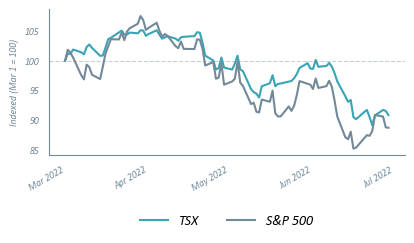

In [35]:
#Match pptx dimensions
fig, ax = plt.subplots(figsize=(4.59, 2.21))

#Plot TSX (indexed to 100 at Mar 1)
ax.plot(tsx_idx.index, tsx_idx, color='#38A4B4', linewidth=1.5, label='TSX')

#Plot S&P 500 (indexed to 100 at Mar 1) on same axis
ax.plot(sp500_idx.index, sp500_idx, color='#72899A', linewidth=1.5, label='S&P 500')

#Add horizontal line at 100 representing starting level
ax.axhline(100, color='#72899A', linewidth=0.8, linestyle='--', alpha=0.4)

#Axis formatting
ax.set_ylabel('Indexed (Mar 1 = 100)', fontsize=7, color='#72899A', style='italic')
ax.set_xlabel('')

#Remove gridlines
ax.grid(False)

#Spine formatting
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#72899A')

#More formatting
ax.tick_params(bottom=False, left=False, labelsize=7, colors='#72899A')

#Set x-axis frequency
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

#Format x-axis labels as "Mar 2022"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rotate x-axis labels 30 degrees and right-align to prevent overlap
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Collect legend handles and labels from the axis
# (only one axis here unlike the VIX/MOVE chart, so no merging needed)
lines1, labels1 = ax.get_legend_handles_labels()

# Place a combined legend below the chart in a single row
# bbox_to_anchor pushes it below the x-axis labels
# ncol=2 puts TSX and S&P 500 side by side
ax.legend(lines1, labels1,
          frameon=False, fontsize=7, ncol=2,
          loc='upper center', bbox_to_anchor=(0.5, -0.32),
          prop={'style': 'italic'})

# Set the figure background to white
fig.patch.set_facecolor('white')

# Manually add bottom margin to prevent the legend overlapping the x-axis labels
# (replaces tight_layout which conflicts with subplots_adjust)
fig.subplots_adjust(bottom=0.22)

# Save at 300 DPI for print quality; bbox_inches='tight' prevents clipping
plt.savefig('/Users/jdawg/Downloads/tsx_sp500.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
ger_data = pd.read_csv(r"/Users/jdawg/Downloads/Germany 2-Year Bond Yield Historical Data.csv")
jpy_data = pd.read_csv(r"/Users/jdawg/Downloads/Japan 2-Year Bond Yield Historical Data.csv")
ca_data = yield_data["2YR"].loc['2022-03-01':'2022-06-30']
us_data = pd.read_csv(r"/Users/jdawg/Downloads/DGS2-2.csv")
uk_data = pd.read_csv(r"/Users/jdawg/Downloads/United Kingdom 2-Year Bond Yield Historical Data.csv")

In [37]:
# Parse dates and set index for each
def prep(df, col_name):
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()
    return df['Open'].rename(col_name)

ger = prep(ger_data, 'Germany')
jpy = prep(jpy_data, 'Japan')
uk  = prep(uk_data, 'UK')

# FRED data (already has datetime index)
us_2y = web.DataReader('DGS2', 'fred', '2022-03-01', '2022-06-30')
us_2y = us_2y['DGS2'].rename('US')

# BoC data for Canada
yield_data.index = pd.to_datetime(yield_data.index)
ca = yield_data['2YR'].loc['2022-03-01':'2022-06-30'].rename('Canada')

# Combine
combined = pd.concat([us_2y, ca, uk, ger, jpy], axis=1)
combined = combined.sort_index().dropna(how='all')

# Forward fill any missing days (holidays etc.)
combined = combined.ffill()

print(combined)

               US  Canada     UK  Germany   Japan
2022-03-01 1.3100 -0.1200 1.0230  -0.5510 -0.0420
2022-03-02 1.5000  0.1400 0.8010  -0.7230 -0.0340
2022-03-03 1.5300  0.0100 1.0770  -0.6420 -0.0360
2022-03-04 1.5000 -0.1000 1.1010  -0.6470 -0.0340
2022-03-06 1.5000 -0.1000 1.0510  -0.6470 -0.0470
...           ...     ...    ...      ...     ...
2022-06-26 3.0400  0.0200 1.9120   0.7940 -0.0820
2022-06-27 3.0800  0.0500 1.9380   0.8050 -0.0750
2022-06-28 3.1000 -0.0100 2.0330   0.8910 -0.0600
2022-06-29 3.0600 -0.0200 2.1130   0.9450 -0.0370
2022-06-30 2.9200 -0.0400 1.9970   0.8320 -0.0460

[112 rows x 5 columns]


In [38]:
def prep(df, col_name):
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()
    return df['Open'].rename(col_name)

ger = prep(ger_data, 'Germany')
jpy = prep(jpy_data, 'Japan')
uk  = prep(uk_data, 'UK')

us_2y = web.DataReader('DGS2', 'fred', '2022-03-01', '2022-06-30')
us_2y = us_2y['DGS2'].rename('US')

yield_data.index = pd.to_datetime(yield_data.index)
ca = yield_data['2YR'].loc['2022-03-01':'2022-06-30'].rename('Canada')

combined = pd.concat([us_2y, ca, uk, ger, jpy], axis=1)
combined = combined.sort_index().ffill()

combined_chg = combined - combined.iloc[0]
print(combined_chg)

               US  Canada      UK  Germany   Japan
2022-03-01 0.0000  0.0000  0.0000   0.0000  0.0000
2022-03-02 0.1900  0.2600 -0.2220  -0.1720  0.0080
2022-03-03 0.2200  0.1300  0.0540  -0.0910  0.0060
2022-03-04 0.1900  0.0200  0.0780  -0.0960  0.0080
2022-03-06 0.1900  0.0200  0.0280  -0.0960 -0.0050
...           ...     ...     ...      ...     ...
2022-06-26 1.7300  0.1400  0.8890   1.3450 -0.0400
2022-06-27 1.7700  0.1700  0.9150   1.3560 -0.0330
2022-06-28 1.7900  0.1100  1.0100   1.4420 -0.0180
2022-06-29 1.7500  0.1000  1.0900   1.4960  0.0050
2022-06-30 1.6100  0.0800  0.9740   1.3830 -0.0040

[112 rows x 5 columns]


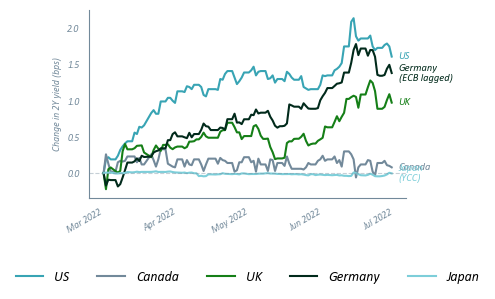

In [39]:
fig, ax = plt.subplots(figsize=(4.56, 2.85))

colors = {
    'US':      '#38A4B4',
    'Canada':  '#72899A',
    'UK':      '#157F17',
    'Germany': '#012A1B',
    'Japan':   '#7DCED9'
}

for country in combined_chg.columns:
    ax.plot(combined_chg.index, combined_chg[country],
            color=colors[country], linewidth=1.5, label=country)

# End-of-line labels
end_labels = {
    'US':      'US',
    'Canada':  'Canada',
    'Germany': 'Germany\n(ECB lagged)',
    'UK': "UK",
    'Japan':   'Japan\n(YCC)',
}
for country, label in end_labels.items():
    last_val = combined_chg[country].dropna().iloc[-1]
    ax.annotate(label,
                xy=(combined_chg.index[-1], last_val),
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=7.5, color=colors[country],
                va='center', style='italic')


ax.axhline(0, color='#72899A', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_ylabel('Change in 2Y yield (bps)', fontsize=7, color='#72899A', style='italic')
ax.set_xlabel('')
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#72899A')
ax.tick_params(bottom=False, left=False, labelsize=7, colors='#72899A')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels,
          frameon=False, fontsize=7, ncol=5,
          loc='upper center', bbox_to_anchor=(0.5, -0.32),
          prop={'style': 'italic'})

fig.patch.set_facecolor('white')
fig.subplots_adjust(bottom=0.22, right=0.82)
plt.savefig('/Users/jdawg/Downloads/global_2y_yields.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/0c/gwf3kkss2ls74cgdgxp9q88r0000gn/T/ipykernel_34822/2552910185.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crude = yf.download("CL=F", start="2022-03-01", end="2022-06-30")
[*********************100%***********************]  1 of 1 completed
/var/folders/0c/gwf3kkss2ls74cgdgxp9q88r0000gn/T/ipykernel_34822/2552910185.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  cadusd = yf.download("CAD=X", start="2022-03-01", end="2022-06-30")
[*********************100%***********************]  1 of 1 completed
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


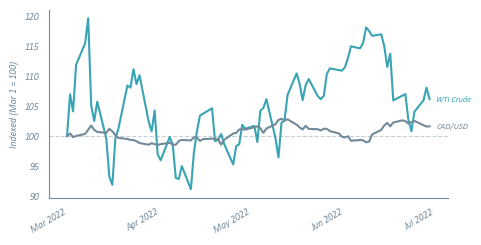

In [40]:
crude = yf.download("CL=F", start="2022-03-01", end="2022-06-30")
cadusd = yf.download("CAD=X", start="2022-03-01", end="2022-06-30")

# Index to 100
crude_idx = crude['Close'] / crude['Close'].iloc[0] * 100
cadusd_idx = cadusd['Close'] / cadusd['Close'].iloc[0] * 100

fig, ax = plt.subplots(figsize=(5.5, 2.85))

ax.plot(crude_idx.index, crude_idx, color='#38A4B4', linewidth=1.5, label='WTI Crude')
ax.plot(cadusd_idx.index, cadusd_idx, color='#72899A', linewidth=1.5, label='CAD/USD')

ax.axhline(100, color='#72899A', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_ylabel('Indexed (Mar 1 = 100)', fontsize=7, color='#72899A', style='italic')
ax.set_xlabel('')
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#72899A')
ax.tick_params(bottom=False, left=False, labelsize=7, colors='#72899A')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# End of line labels
for series, label, color in [
    (crude_idx, 'WTI Crude', '#38A4B4'),
    (cadusd_idx, 'CAD/USD', '#72899A')
]:
    last_val = series.dropna().iloc[-1]
    ax.annotate(label,
                xy=(series.dropna().index[-1], last_val),
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=6, color=color,
                va='center', style='italic')

fig.patch.set_facecolor('white')
fig.subplots_adjust(bottom=0.22, right=0.85)
plt.savefig('/Users/jdawg/Downloads/crude_cadusd.png', dpi=300, bbox_inches='tight')
plt.show()